<a href="https://colab.research.google.com/github/xDanilog27/Bussiness-Inteligent/blob/main/Reto_Challenge_6_Modelos_Neuronales_Riesgo_Cr%C3%A9dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Reto Challenge 7

Implementar dos modelos neuronales, uno de tipo ADALINE y otro de tipo MADALINE (Multi-Adaptive Linea, Sin Bias) para evaluar el riesgo crédito en el otorgamiento de créditos de consumo utilizando para ello como variable de referencia el Score (Función Activación Relu) así como las variables socioeconómicas de entrada: Edad, Hijos, Personas a Cargo, Estrato, Ingresos, Egresos, Monto, Plazo, Cuota (9 variables).

Variables: 'Edad','Hijos','Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)'


1. Instalación de las librerias y carga de las librerias

In [ ]:
!pip install tensorflow #Libreria nativa para el diseño de redes neuronales

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')



2. Se procede con la carga de los datos

In [2]:
nxl='/content/drive/MyDrive/Retos/Reto Challenge 6 - Modelos Neuronales/6. SolicitantesCrédito(USD).xlsx'
XDB=pd.read_excel(nxl,sheet_name=1) #Base de datos triple A
XDB=XDB[['Edad','Hijos','Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)','Score']]
display(XDB)


#Separamos las variables por entrada y salida
XD=np.array(XDB[['Edad','Hijos','Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']])
yd=np.array(XDB['Score'])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd/np.max(yd,axis=0)
print("Los datos de entrada son:\n",XDn)


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Score
0,38,1,0,3,1356.14400,1685.622667,625.562230,48,18.375890,582.478943
1,51,6,1,4,286.01600,364.462000,140.031984,36,5.062492,479.839966
2,37,2,0,3,517.46325,629.208889,284.564492,36,10.287688,417.653107
3,29,1,0,2,473.27000,551.616889,309.647588,24,15.458878,316.791107
4,42,3,4,2,750.09175,806.715778,500.663578,24,24.995180,441.809570
...,...,...,...,...,...,...,...,...,...,...
5837,48,0,0,3,1207.84800,753.801111,748.041791,36,27.043503,550.980408
5838,31,2,0,5,1472.77200,953.812889,870.793819,48,25.579568,659.471375
5839,38,0,0,3,773.01975,672.910667,594.947894,36,21.508792,465.011536
5840,43,1,2,2,635.50175,780.691556,305.580539,36,11.047468,423.237305


Los datos de entrada son:
 [[0.52054795 0.14285714 0.         ... 0.15349289 0.8        0.02045638]
 [0.69863014 0.85714286 0.2        ... 0.03435935 0.6        0.00563566]
 [0.50684932 0.28571429 0.         ... 0.06982299 0.6        0.01145244]
 ...
 [0.52054795 0.         0.         ... 0.14598111 0.6        0.02394398]
 [0.5890411  0.14285714 0.4        ... 0.07497965 0.6        0.01229825]
 [0.50684932 0.14285714 0.4        ... 0.246751   0.6        0.04047237]]


3. Se implementa el Modelo Neuronal Adaline


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0133
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0107
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0065
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0034
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0028
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0020
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0

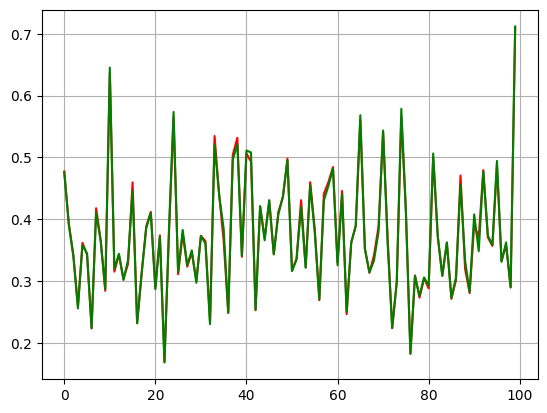

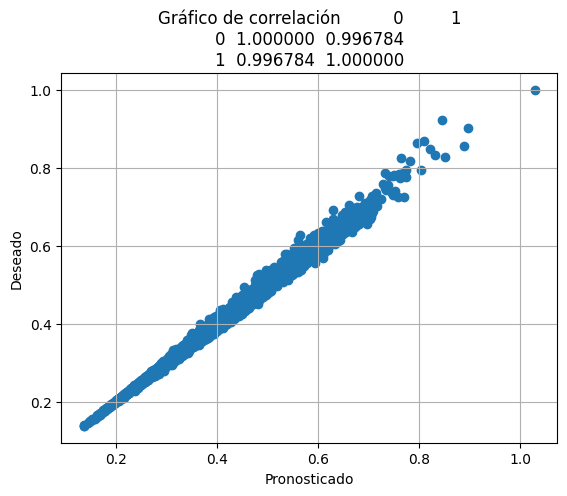

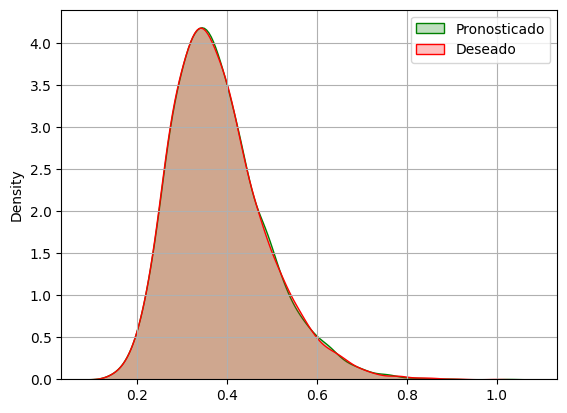

In [13]:
#Adaptive Linear (Relu- Regresión Lineal)
adaline=tf.keras.Sequential([tf.keras.layers.Dense(units=1,input_shape=(9,),use_bias=False, activation='relu')])

# Aqui se cargan los pesos con el archivo

adaline.load_weights("/content/drive/MyDrive/Retos/Reto Challenge 6 - Modelos Neuronales/pesos_adaline_L.weights.h5")

adaline.compile(optimizer='sgd',loss='mse')  #mse: Error entre ydn y lo que entrega la red
                                              #sdg: Método gradiente para reducir el error
adaline.summary()
history=adaline.fit(XDn,ydn,epochs=100) #epochs: Numero de veces que recorre la tabla

#Evaluamos el comportamiento del modelo
yp=adaline.predict(XDn)
dfcorr=pd.DataFrame(np.column_stack((yp,ydn))) #Comparar comportamiento modelo
print("La correlación entre yp-ydn es:\n",dfcorr.corr())

#Obtenemos las conexiones nerviosas
w=adaline.get_weights()
print("Los pesos de la red neuronal son:\n",w)

#Gráficamos los resultados
plt.figure()
plt.plot(ydn[0:100,],'r',label='Deseado')
plt.plot(yp[0:100],'g',label='Pronosticado')
plt.grid(True)
plt.show()

#Gráfico de correlación
#Debe haber una predominancia de la diagonal principal
plt.figure()
plt.scatter(yp,ydn)
plt.grid(True)

plt.xlabel('Pronosticado')
plt.ylabel('Deseado')
plt.title('Gráfico de correlación'+str(dfcorr.corr()))
plt.show()

#Gráfico de distribuciones
plt.figure()
sns.kdeplot(x=yp.flatten(),label='Pronosticado', fill=True, color='g')
sns.kdeplot(x=ydn.flatten(),label='Deseado', fill=True, color='r')
plt.grid(True)
plt.legend()
plt.show()


4. Se evalua solo una persona

In [16]:
Xnp=[[45,1,0,4,2000,1000,1200,24,60]]
Xnpn=Xnp/np.max(XD,axis=0) #Normalizar datos de entrada
print("Los datos de entrada son:\n",Xnpn)
ypnp=adaline.predict(Xnpn)
print("El score estimado es:\n",ypnp*np.max(yd)) #Salida Desnormalizar Máximo


Los datos de entrada son:
 [[0.61643836 0.14285714 0.         0.66666667 0.66780533 0.31829503
  0.29444147 0.4        0.0667931 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
El score estimado es:
 [[733.69725307]]


5. Se crea el Modelo Madaline

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0027
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0024
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0021
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0016
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0016
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0013
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0012
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0

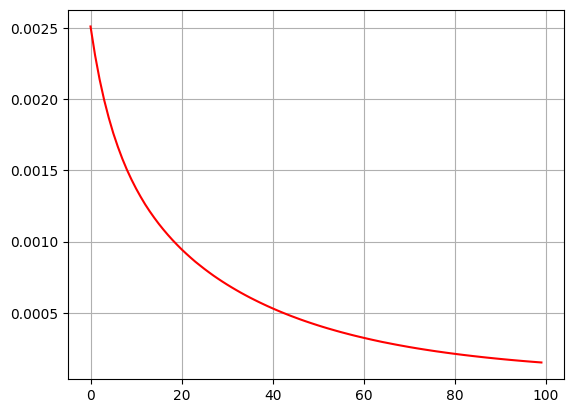

Los efectos independientes son:
 [[ 0.2019049 ]
 [ 0.29933488]
 [-0.1707982 ]
 [ 0.29801795]
 [ 0.1006157 ]
 [ 0.30022293]
 [ 0.28056198]
 [ 0.2911517 ]
 [-0.20264566]]


In [19]:
madaline=tf.keras.Sequential([
    tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
    tf.keras.layers.Dense(units=1,use_bias=False)])

madaline.load_weights("/content/drive/MyDrive/Retos/Reto Challenge 6 - Modelos Neuronales/pesos_madaline_L.weights.h5")

# Madalines> Multi adaptive lineal / Multiples regresiones lineales
madaline.summary()
madaline.compile(optimizer='sgd',loss='mse')
history2=madaline.fit(XDn,ydn,epochs=100)

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es:\n",dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history2.history['loss']

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()


# Efectos indepedientes de las Variables
WC=madaline.get_weights()
W=WC[0];C=WC[1]

a=W@C #Estos son los efectos independientes
print("Los efectos independientes son:\n",a)

# Esto valores de los efectos independietes explican las varibles, dependiendo de la variable puede ser positiva o negativa comm los egresos que deben ser negativos y los ingresos positivos
# Edad negativo, ingresos positivo, egresoso negativo, monto negativo


6. Evaluamos la nueva persona

In [20]:
Xnp=[[45,1,0,4,2000,1000,1200,24,60]]
Xnpn=Xnp/np.max(XD,axis=0) #Normalizar datos de entrada
print("Los datos de entrada son:\n",Xnpn)
ypnp=madaline.predict(Xnpn)
print("El score estimado es:\n",ypnp*np.max(yd)) #Salida Desnormalizar Máximo

#

Los datos de entrada son:
 [[0.61643836 0.14285714 0.         0.66666667 0.66780533 0.31829503
  0.29444147 0.4        0.0667931 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
El score estimado es:
 [[635.22805077]]
